# Machine Learning Final Project  
## Project Overview
This project evaluates three supervised learning models on two classification datasets using scikit-learn:
- Iris
- Heart Disease

The models compared are:
- Logistic Regression
- k-Nearest Neighbors (KNN)
- Decision Tree

The workflow includes dataset exploration, preprocessing, model development, hyperparameter tuning, evaluation, and comparison with prior published work.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

plt.rcParams["figure.figsize"] = (6, 4)

## 2. Dataset 1: Iris

The Iris dataset is a classic multiclass classification dataset with 150 samples, 4 numeric features, and 3 target classes.

In [2]:
iris = load_iris(as_frame=True)
X_iris = iris.data
y_iris = iris.target

print("Iris shape:", X_iris.shape)
print("\nFeatures:")
print(X_iris.columns.tolist())
print("\nTarget classes:")
print(iris.target_names)
X_iris.head()

Iris shape: (150, 4)

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target classes:
['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
print(X_iris.describe())
print("\nClass counts:")
print(y_iris.value_counts())

       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count         150.000000        150.000000         150.000000        150.000000
mean            5.843333          3.057333           3.758000          1.199333
std             0.828066          0.435866           1.765298          0.762238
min             4.300000          2.000000           1.000000          0.100000
25%             5.100000          2.800000           1.600000          0.300000
50%             5.800000          3.000000           4.350000          1.300000
75%             6.400000          3.300000           5.100000          1.800000
max             7.900000          4.400000           6.900000          2.500000

Class counts:
target
0    50
1    50
2    50
Name: count, dtype: int64


## 3. Dataset 2: Heart Disease

This project uses a heart disease dataset with 303 rows. The target variable is `AHD`, which indicates whether heart disease is present.

In [4]:
heart = pd.read_csv("heart.csv")
heart = heart.drop(columns=["Unnamed: 0"])
X_heart = heart.drop(columns=["AHD"])
y_heart = (heart["AHD"] == "Yes").astype(int)

print("Heart shape:", X_heart.shape)
print("\nColumns:")
print(X_heart.columns.tolist())
X_heart.head()

Heart shape: (303, 13)

Columns:
['Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal']


,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal


In [5]:
print(X_heart.dtypes)
print("\nMissing values:")
print(heart.isna().sum())
print("\nTarget counts:")
print(y_heart.value_counts())

Age            int64
Sex            int64
ChestPain     object
RestBP         int64
Chol           int64
Fbs            int64
RestECG        int64
MaxHR          int64
ExAng          int64
Oldpeak      float64
Slope          int64
Ca           float64
Thal          object
dtype: object

Missing values:
Age          0
Sex          0
ChestPain    0
RestBP       0
Chol         0
Fbs          0
RestECG      0
MaxHR        0
ExAng        0
Oldpeak      0
Slope        0
Ca           4
Thal         2
AHD          0
dtype: int64

Target counts:
AHD
0    164
1    139
Name: count, dtype: int64


## 4. Preprocessing

For Iris, scaling is used because Logistic Regression and KNN are sensitive to feature scale.  
For the Heart dataset, numeric columns are scaled for Logistic Regression and KNN, while categorical columns are one-hot encoded.

In [6]:
cat_cols = X_heart.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_heart.columns if c not in cat_cols]

iris_pre = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

heart_pre_scaled = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

heart_pre_tree = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

## 5. Model Development and Hyperparameter Tuning

GridSearchCV is used for each model.

In [7]:
iris_searches = {
    "Logistic Regression": GridSearchCV(
        Pipeline([
            ("pre", iris_pre),
            ("clf", LogisticRegression(max_iter=1000))
        ]),
        {"clf__C": [0.1, 1, 10]},
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    ),
    "KNN": GridSearchCV(
        Pipeline([
            ("pre", iris_pre),
            ("clf", KNeighborsClassifier())
        ]),
        {"clf__n_neighbors": [3, 5, 7], "clf__weights": ["uniform", "distance"]},
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    ),
    "Decision Tree": GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        {"max_depth": [None, 3, 5], "min_samples_split": [2, 5]},
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    )
}

heart_searches = {
    "Logistic Regression": GridSearchCV(
        Pipeline([
            ("pre", heart_pre_scaled),
            ("clf", LogisticRegression(max_iter=1000))
        ]),
        {"clf__C": [0.1, 1, 10]},
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    ),
    "KNN": GridSearchCV(
        Pipeline([
            ("pre", heart_pre_scaled),
            ("clf", KNeighborsClassifier())
        ]),
        {"clf__n_neighbors": [5, 7, 9], "clf__weights": ["uniform", "distance"]},
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    ),
    "Decision Tree": GridSearchCV(
        Pipeline([
            ("pre", heart_pre_tree),
            ("clf", DecisionTreeClassifier(random_state=42))
        ]),
        {"clf__max_depth": [None, 3, 5], "clf__min_samples_split": [2, 5], "clf__criterion": ["gini", "entropy"]},
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    )
}

In [8]:
def evaluate_search(search, X_train, X_test, y_train, y_test, multiclass=False):
    search.fit(X_train, y_train)
    best = search.best_estimator_
    preds = best.predict(X_test)

    results = {
        "best_params": search.best_params_,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, average="weighted"),
        "recall": recall_score(y_test, preds, average="weighted"),
        "f1": f1_score(y_test, preds, average="weighted"),
        "cv_accuracy": search.best_score_,
        "confusion_matrix": confusion_matrix(y_test, preds)
    }

    if hasattr(best, "predict_proba"):
        probs = best.predict_proba(X_test)
        if multiclass:
            results["roc_auc"] = roc_auc_score(y_test, probs, multi_class="ovr")
        else:
            results["roc_auc"] = roc_auc_score(y_test, probs[:, 1])

    return best, preds, results

iris_models = {}
iris_results = {}
iris_preds = {}

for name, search in iris_searches.items():
    model, preds, results = evaluate_search(search, X_train_i, X_test_i, y_train_i, y_test_i, multiclass=True)
    iris_models[name] = model
    iris_preds[name] = preds
    iris_results[name] = results

heart_models = {}
heart_results = {}
heart_preds = {}

for name, search in heart_searches.items():
    model, preds, results = evaluate_search(search, X_train_h, X_test_h, y_train_h, y_test_h, multiclass=False)
    heart_models[name] = model
    heart_preds[name] = preds
    heart_results[name] = results

## 6. Results Tables

In [9]:
iris_table = pd.DataFrame({
    name: {
        "Best Parameters": str(res["best_params"]),
        "Accuracy": round(res["accuracy"], 4),
        "Precision": round(res["precision"], 4),
        "Recall": round(res["recall"], 4),
        "F1": round(res["f1"], 4),
        "ROC-AUC": round(res["roc_auc"], 4),
        "CV Accuracy": round(res["cv_accuracy"], 4)
    }
    for name, res in iris_results.items()
}).T

heart_table = pd.DataFrame({
    name: {
        "Best Parameters": str(res["best_params"]),
        "Accuracy": round(res["accuracy"], 4),
        "Precision": round(res["precision"], 4),
        "Recall": round(res["recall"], 4),
        "F1": round(res["f1"], 4),
        "ROC-AUC": round(res["roc_auc"], 4),
        "CV Accuracy": round(res["cv_accuracy"], 4)
    }
    for name, res in heart_results.items()
}).T

print("IRIS RESULTS")
display(iris_table)
print("\nHEART RESULTS")
display(heart_table)

IRIS RESULTS


,Best Parameters,Accuracy,Precision,Recall,F1,ROC-AUC,CV Accuracy
Logistic Regression,{'clf__C': 1},0.9333,0.9333,0.9333,0.9333,0.9967,0.9583
KNN,"{'clf__n_neighbors': 3, 'clf__weights': 'dista...",0.9667,0.9697,0.9667,0.9666,1.0,0.9667
Decision Tree,"{'max_depth': None, 'min_samples_split': 2}",0.9333,0.9333,0.9333,0.9333,0.95,0.9417



HEART RESULTS


,Best Parameters,Accuracy,Precision,Recall,F1,ROC-AUC,CV Accuracy
Logistic Regression,{'clf__C': 0.1},0.8689,0.8766,0.8689,0.869,0.9589,0.8305
KNN,"{'clf__n_neighbors': 5, 'clf__weights': 'unifo...",0.9016,0.9096,0.9016,0.9017,0.9648,0.8139
Decision Tree,"{'clf__criterion': 'entropy', 'clf__max_depth'...",0.8033,0.8056,0.8033,0.8036,0.8339,0.7686


## 7. Confusion Matrices

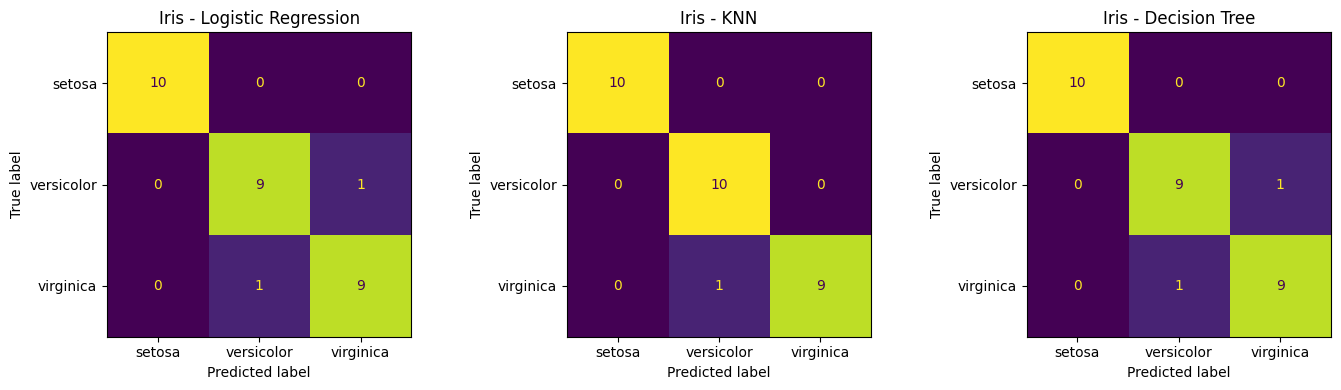

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, res) in zip(axes, iris_results.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=res["confusion_matrix"], display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Iris - {name}")
plt.tight_layout()
plt.show()

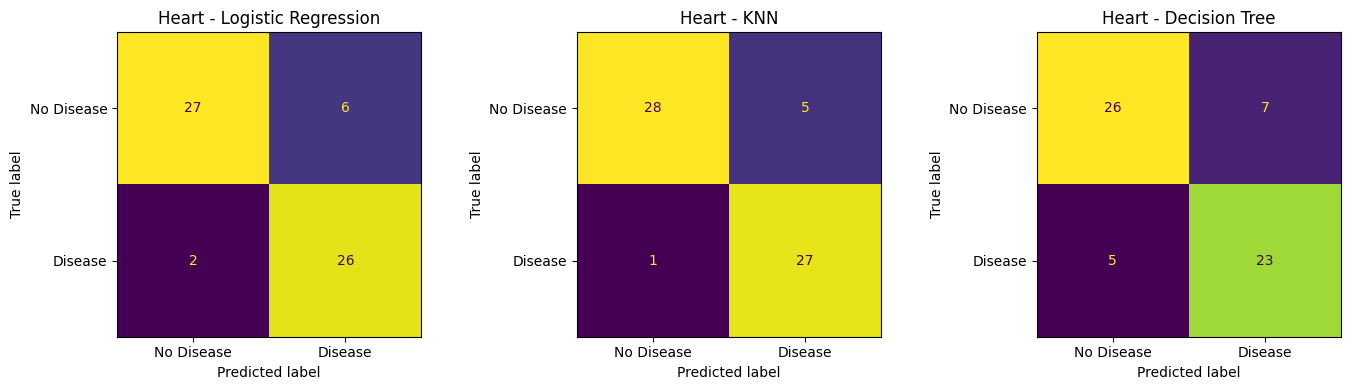

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, res) in zip(axes, heart_results.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=res["confusion_matrix"], display_labels=["No Disease", "Disease"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Heart - {name}")
plt.tight_layout()
plt.show()

## 8. ROC Curves

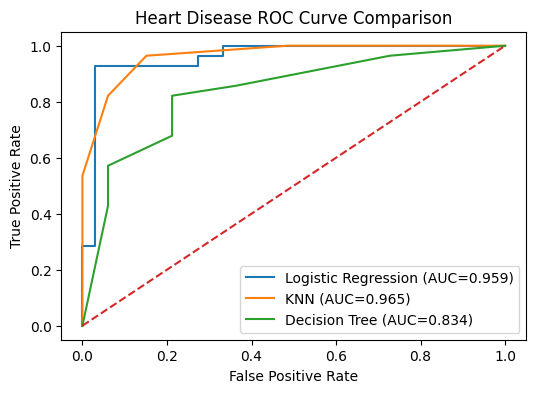

In [12]:
plt.figure(figsize=(6, 4))
for name, model in heart_models.items():
    probs = model.predict_proba(X_test_h)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_h, probs)
    auc = roc_auc_score(y_test_h, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Heart Disease ROC Curve Comparison")
plt.legend()
plt.show()

## 9. Interpretation

- On the Iris dataset, all three models performed well. KNN achieved the highest test accuracy at about 96.7%.
- On the Heart dataset, KNN achieved the highest test accuracy at about 90.2%, while Logistic Regression achieved a very strong ROC-AUC of about 0.959.
- Decision Tree was the weakest model on the Heart dataset, which suggests it may have been more sensitive to the limited sample size and split structure.

## 10. Conclusion

This project showed that model performance changes depending on the dataset.  
The Iris dataset was easier to classify because it is small, clean, and well-structured.  
The Heart dataset was more challenging, but the tuned KNN and Logistic Regression models still produced strong results.

Overall:
- **Best Iris model:** KNN
- **Best Heart model by accuracy:** KNN
- **Best Heart model by ROC-AUC and stability:** Logistic Regression